# Machine Learning Model Training

## Overview
This section covers the process of training a machine learning model we are using linear regression models:
- LinearRegression
- Lasso
- Ridge 
- ElasticNet 

## Steps

### 1. Data Preparation
- Load and explore the dataset
- Handle missing values
- Perform feature scaling/normalization
- Split data into training and testing sets

### 2. Model Selection
- Choose appropriate algorithm based on problem type
- Consider model complexity and interpretability
- Evaluate multiple models if needed

### 3. Model Training
- Fit the model on training data
- Monitor training progress
- Adjust hyperparameters as needed

### 4. Model Evaluation
- Evaluate on test set
- Calculate relevant metrics (accuracy, precision, recall, F1-score, etc.)
- Analyze confusion matrix and ROC curve
- Cross-validate results

### 5. Hyperparameter Tuning
- Use grid search or random search
- Optimize for best performance
- Avoid overfitting



In [1]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("preprocessed_data.csv")
data.describe()

,id,carat,cut,color,clarity,depth,table,x,price
count,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000
mean,96786.000000,0.790688,4.132152,3.516157,3.975084,61.820574,57.227675,5.715312,3969.155414
std,55879.856166,0.462688,0.994157,1.623091,1.501776,1.081704,1.918844,1.109422,4034.374138
min,0.000000,0.200000,1.000000,1.000000,1.000000,52.100000,49.000000,0.000000,326.000000
25%,48393.000000,0.400000,3.000000,2.000000,3.000000,61.300000,56.000000,4.700000,951.000000
50%,96786.000000,0.700000,4.000000,4.000000,4.000000,61.900000,57.000000,5.700000,2401.000000
75%,145179.000000,1.030000,5.000000,5.000000,5.000000,62.400000,58.000000,6.510000,5408.000000
max,193572.000000,3.500000,5.000000,7.000000,8.000000,71.600000,79.000000,9.650000,18818.000000


In [3]:
data.head()

,id,carat,cut,color,clarity,depth,table,x,price
0,0,1.52,4,3,4,62.2,58.0,7.27,13619
1,1,2.03,3,7,2,62.0,58.0,8.06,13387
2,2,0.70,5,4,5,61.2,57.0,5.69,2772
3,3,0.32,5,4,5,61.6,56.0,4.38,666
4,4,1.70,4,4,4,62.6,59.0,7.65,14453


In [4]:
data.drop('id',axis=1,inplace=True)

In [5]:
print(data)

        carat  cut  color  clarity  depth  table     x  price
0        1.52    4      3        4   62.2   58.0  7.27  13619
1        2.03    3      7        2   62.0   58.0  8.06  13387
2        0.70    5      4        5   61.2   57.0  5.69   2772
3        0.32    5      4        5   61.6   56.0  4.38    666
4        1.70    4      4        4   62.6   59.0  7.65  14453
...       ...  ...    ...      ...    ...    ...   ...    ...
193568   0.31    5      1        6   61.1   56.0  4.35   1130
193569   0.70    4      4        6   60.3   58.0  5.75   2874
193570   0.73    3      3        3   63.1   57.0  5.72   3036
193571   0.34    3      1        3   62.9   55.0  4.45    681
193572   0.71    2      2        2   60.8   64.0  5.73   2258

[193573 rows x 8 columns]


In [6]:
X=data.drop(labels=['price'],axis=1)
Y=data[['price']]

In [7]:
X.shape 

(193573, 7)

In [8]:
Y.shape

(193573, 1)

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.25,random_state=42)

In [10]:
scaler=StandardScaler()

In [ ]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.ransform(X_test)

In [12]:
X_train_scaled

array([[ 0.47201886,  0.8733707 ,  1.52763396, ...,  0.2579731 ,
        -0.64043968,  0.60646013],
       [ 0.62309937,  0.8733707 ,  0.91152604, ...,  0.81246294,
        -1.16126779,  0.73251523],
       [ 2.65189475, -0.13210958,  1.52763396, ..., -1.86757127,
         1.44287279,  2.23617253],
       ...,
       [ 0.92526038, -0.13210958,  0.29541811, ...,  0.90487791,
         0.40121656,  0.99362938],
       [-1.03878621, -1.13758985,  0.29541811, ..., -0.66617663,
        -0.64043968, -1.21233492],
       [-1.03878621, -1.13758985,  0.29541811, ..., -0.01927182,
         0.92204468, -1.23934673]])

### Lets do some model training

Models we are using :
| Model | Regularization Type | Key Feature |
| :--- | :---: | :--- |
| **Linear Regression** | None | Fits a straight line (or hyperplane) by minimizing squared errors. |
| **Ridge** | L2 | Adds a penalty equal to the square of the magnitude of coefficients. Helps with multicollinearity. |
| **Lasso** | L1 | Adds a penalty equal to the absolute value of the magnitude of coefficients. Can shrink some coefficients to zero (**feature selection**). |
| **ElasticNet** | L1 + L2 | Combines both Lasso and Ridge penalties. Good when there are multiple correlated features. |

In [13]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,accuracy_score


In [14]:
import numpy as np

In [15]:
models = {
    'linear' : LinearRegression(),
    'Lasso' : Lasso(),
    'Ridge': Ridge(),
    'Elastic' : ElasticNet()
    }

In [16]:
def evaluate_model(model,true,predicted):
    print("-"*90)
    print(model)
    print("-"*90)
    print(f"MAE : {mean_absolute_error(true,predicted)}")
    print(f"MSE : {mean_squared_error(true,predicted)}")
    print(f"R2_score : {r2_score(true,predicted)}")


In [17]:
list(models)

['linear', 'Lasso', 'Ridge', 'Elastic']

In [18]:
models.keys()

dict_keys(['linear', 'Lasso', 'Ridge', 'Elastic'])

In [19]:
for i in models.values():
    model = i
    model.fit(X_train_scaled,y_train)
    y_predicted=model.predict(X_test_scaled)
    evaluate_model(i,y_test,y_predicted)

------------------------------------------------------------------------------------------
LinearRegression()
------------------------------------------------------------------------------------------
MAE : 678.9936271952781
MSE : 1036979.1109981276
R2_score : 0.9361048608513708
------------------------------------------------------------------------------------------
Lasso()
------------------------------------------------------------------------------------------
MAE : 680.2273601709369
MSE : 1037178.2516684177
R2_score : 0.9360925904780302
------------------------------------------------------------------------------------------
Ridge()
------------------------------------------------------------------------------------------
MAE : 679.0352805571983
MSE : 1036981.2259145796
R2_score : 0.9361047305373851
------------------------------------------------------------------------------------------
ElasticNet()
------------------------------------------------------------------------------

In [20]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    ridge,
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'alpha': 0.1}
0.9368659874928241


In [21]:
from sklearn.linear_model import Lasso

lasso = Lasso()

params = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    lasso,
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'alpha': 0.01}
0.9368659874566777


In [22]:
from sklearn.linear_model import ElasticNet

elastic=ElasticNet()

params={
    'alpha' : [0.0001,0.01,0.1,1,10],
    'l1_ratio' : [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid= GridSearchCV(
    elastic,
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'alpha': 0.0001, 'l1_ratio': 0.9}
0.9368659839818603


We can see that our best R2_score is 0.936 
- hyperparameter tuning helped us improved ElasticNet algorithm 
    - R2_score : 0.84 -> 0.93

In [23]:
model_Elastic = ElasticNet(alpha=0.001,l1_ratio=0.9)
model_Elastic.fit(X_train_scaled,y_train)
y_predicted=model_Elastic.predict(X_test_scaled)
evaluate_model(model_Elastic,y_test,y_predicted)

------------------------------------------------------------------------------------------
ElasticNet(alpha=0.001, l1_ratio=0.9)
------------------------------------------------------------------------------------------
MAE : 679.602398981
MSE : 1037028.7954744964
R2_score : 0.9361017994622864


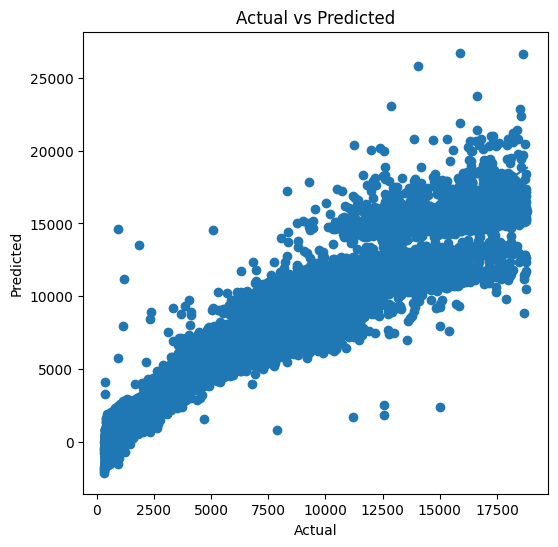

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_predicted)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

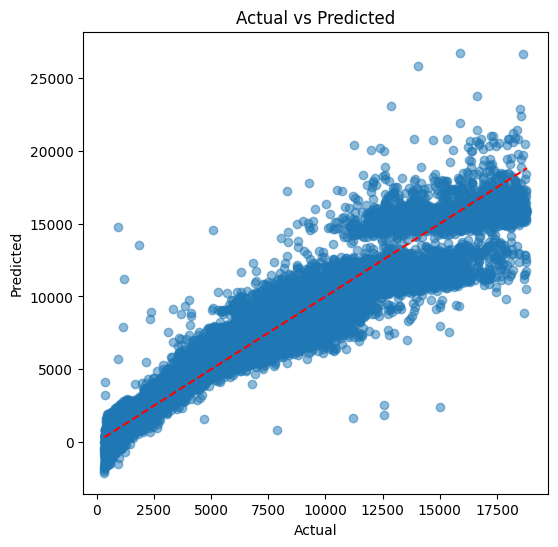

In [25]:
best_model = LinearRegression()
best_model.fit(X_train_scaled,y_train)
y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')

plt.show()


In [26]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_.ravel()
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

print(coef_df)

   Feature  Coefficient
0    carat  6423.473656
6        x -2266.637773
3  clarity   650.643857
2    color  -463.908864
4    depth  -137.873402
1      cut    70.256064
5    table   -68.061138



The DataFrame shows each feature with its coefficient value for Linear Regression model:

- `carat: 6423.47` means the model gives the strongest positive weight to `carat`.
- `x: -2266.64` means the model gives a negative weight to `x`.
- `clarity: 650.64`, `color: -463.91`, etc. show how each feature contributes.

Since the model was trained on scaled features (`X_train_scaled`), these coefficients represent the effect per standardized feature unit, not the original raw feature unit. Positive coefficients increase predicted `price` as the feature rises, negative coefficients decrease predicted `price`.